### Name: Jivan Sawant
### Roll No : TEBD23277
### Practical no :1 

PROBLEM STATEMENT:
Perform the following operations using Python on any open source dataset (e.g., data.csv)
1. Import all the required Python Libraries.
2. Locate an open source data from the web (e.g., https://www.kaggle.com). Provide a clear description of the
data and its source (i.e., URL of the web site).
3. Load the Dataset into pandas dataframe.
4. Data Preprocessing: check for missing values in the data using pandas isnull(), describe() function to get
some initial statistics. Provide variable descriptions. Types of variables etc. Check the dimensions of the
data frame.
5. Data Formatting and Data Normalization: Summarize the types of variables by checking the data types (i.e.,
character, numeric, integer, factor, and logical) of the variables in the data set. If variables are not in the
correct data type, apply proper type conversions.
6. Turn categorical variables into quantitative variables in Python.

In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load dataset 
df = pd.read_csv("1student_performance_raw.csv")
df.head()

,Gender,StudyHours,Attendance,Marks,Result
0,Male,2.0,99.0,200.0,Fail
1,Female,5.0,150.0,64.0,Pass
2,Male,8.0,45.0,62.0,Fail
3,Male,9.0,55.0,98.0,Fail
4,Male,9.0,68.0,95.0,Fail


In [ ]:
# data preprocessing
# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

# Shape and Size
print("\nShape of dataset:", df.shape)
print("Size of dataset:", df.size)

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Statistical Summary:
       StudyHours  Attendance       Marks
count  108.000000  108.000000  108.000000
mean     5.101852   70.388889   70.907407
std      2.794988   18.804371   22.800860
min      1.000000   40.000000   35.000000
25%      3.000000   57.000000   52.750000
50%      5.000000   70.500000   68.500000
75%      7.250000   85.500000   87.250000
max      9.000000  150.000000  200.000000

Shape of dataset: (120, 5)
Size of dataset: 600

Missing Values:
Gender         0
StudyHours    12
Attendance    12
Marks         12
Result         0
dtype: int64


In [ ]:
# Handle missing values using mean
df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nAfter Handling Missing Values:")
print(df.isnull().sum())


After Handling Missing Values:
Gender        0
StudyHours    0
Attendance    0
Marks         0
Result        0
dtype: int64


In [ ]:
#  categorical column

df['Result'] = ['Pass' if x > 50 else 'Fail' for x in df['Marks']]

In [ ]:
# Data types of each column
print("\nData Types:\n", df.dtypes)


Data Types:
 Gender            str
StudyHours    float64
Attendance    float64
Marks         float64
Result            str
dtype: object


In [ ]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# 👉 Print BEFORE normalization
print("Before Normalization:")
print(df[numeric_cols].head())

Before Normalization:
   StudyHours  Attendance     Marks
0       0.125    0.536364  1.000000
1       0.500    1.000000  0.175758
2       0.875    0.045455  0.163636
3       1.000    0.136364  0.381818
4       1.000    0.254545  0.363636


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

# Min-Max Normalization
for col in numeric_cols:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

print("\nAfter Normalization:")
print(df.head())


After Normalization:
   Gender  StudyHours  Attendance     Marks Result
0    Male       0.125    0.536364  1.000000   Pass
1  Female       0.500    1.000000  0.175758   Pass
2    Male       0.875    0.045455  0.163636   Pass
3    Male       1.000    0.136364  0.381818   Pass
4    Male       1.000    0.254545  0.363636   Pass


In [ ]:
#  BEFORE encoding
print("Before Encoding:")
print(df.head())

Before Encoding:
   Gender  StudyHours  Attendance     Marks Result
0    Male       0.125    0.536364  1.000000   Pass
1  Female       0.500    1.000000  0.175758   Pass
2    Male       0.875    0.045455  0.163636   Pass
3    Male       1.000    0.136364  0.381818   Pass
4    Male       1.000    0.254545  0.363636   Pass


In [ ]:

# Step 1: Fill missing values
df = df.fillna(df.mean(numeric_only=True))

#Categorical variables are converted into numerical variables using one-hot encoding.
# Step 2: Now encoding
df_encoded = pd.get_dummies(df).astype(int)

print("\nAfter Encoding:")
print(df_encoded.head())


After Encoding:
   StudyHours  Attendance  Marks  Gender_Female  Gender_Male  Result_Fail
0           0           0      1              0            1            1
1           0           1      0              1            0            1
2           0           0      0              0            1            1
3           1           0      0              0            1            1
4           1           0      0              0            1            1


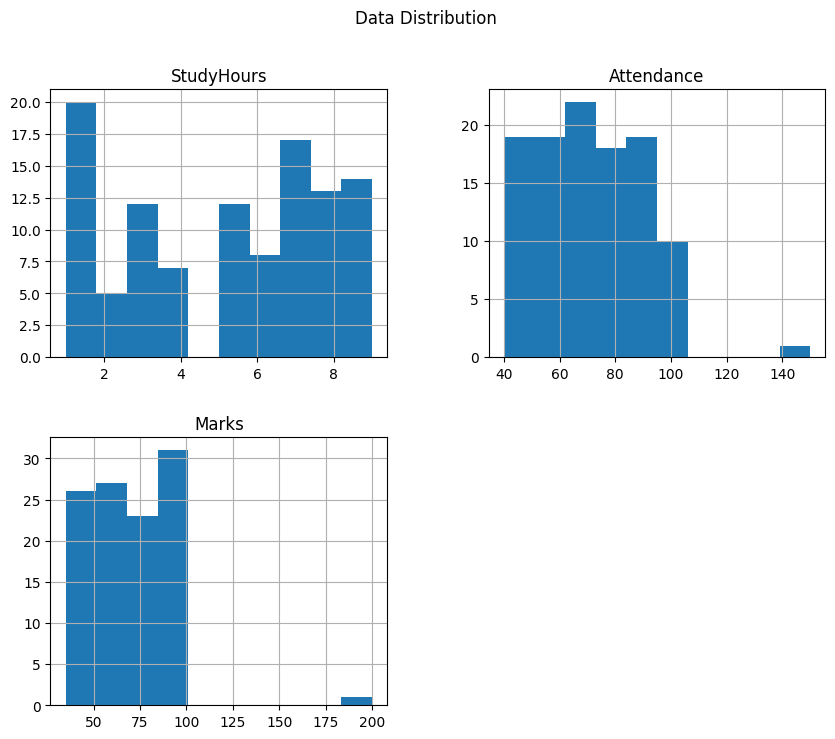

In [ ]:
# Histogram
df_encoded.hist(figsize=(10,8))
plt.suptitle("Data Distribution")
plt.show()